In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [ ]:
df=pd.read_csv("/content/AIML Dataset.csv")

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1859327 entries, 0 to 1859326
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 156.0+ MB


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,1857446
1.0,1880


In [ ]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0.0,1859326


In [ ]:
df.isnull().sum().sum()

np.int64(2)

In [ ]:
df.shape[0]


1859327

In [ ]:
round(df["isFraud"].value_counts()[1] / df.shape[0] * 100, 2)

np.float64(0.1)

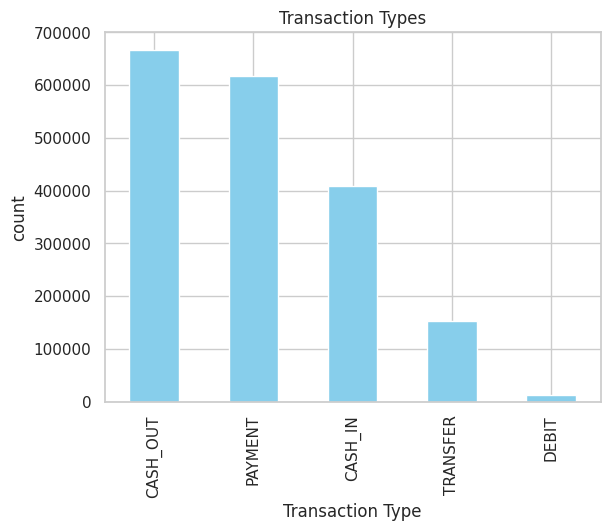

In [ ]:
df["type"].value_counts().plot(kind="bar",title="Transaction Types",color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("count")
plt.show()

In [ ]:
fraud_by_type

,isFraud
type,
TRANSFER,0.006058
CASH_OUT,0.001419
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


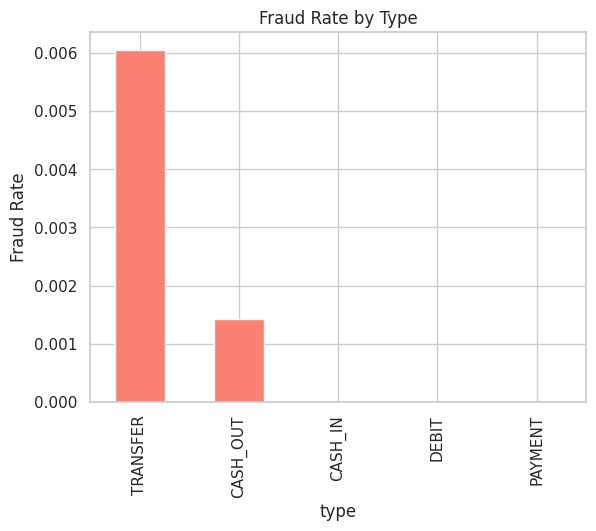

In [ ]:
fraud_by_type =df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar",title="Fraud Rate by Type",color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [ ]:
df["amount"].describe().astype(int)

,amount
count,1859327
mean,161733
std,267697
min,0
25%,13302
50%,79387
75%,217822
max,10000000


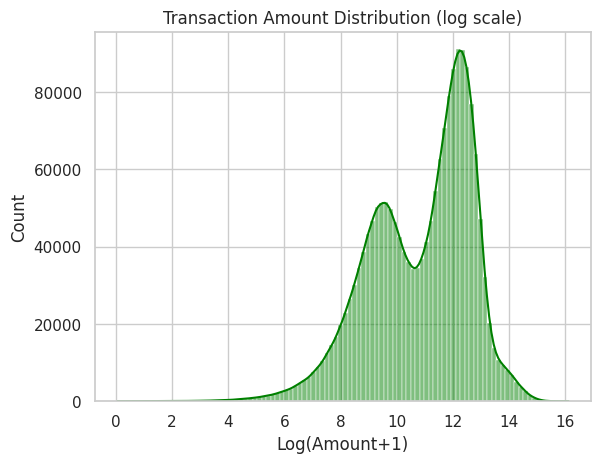

In [ ]:
sns.histplot(np.log1p(df["amount"]),bins=100,kde=True,color="green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount+1)")
plt.show()

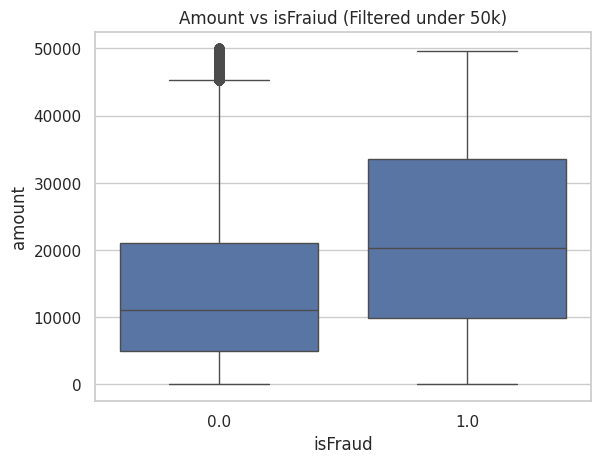

In [ ]:
sns.boxplot(data=df[df["amount"]<50000],x="isFraud",y="amount")
plt.title("Amount vs isFraiud (Filtered under 50k)")
plt.show()

In [ ]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [ ]:
df["balanceDiffOrig"]=df["oldbalanceOrg"]-df["newbalanceOrig"]
df["balanceDiffDest"]=df["newbalanceDest"]-df["oldbalanceDest"]

In [ ]:
(df["balanceDiffOrig"]<0).sum()

np.int64(409080)

In [ ]:
(df["balanceDiffDest"]<0).sum()

np.int64(364106)

In [ ]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0


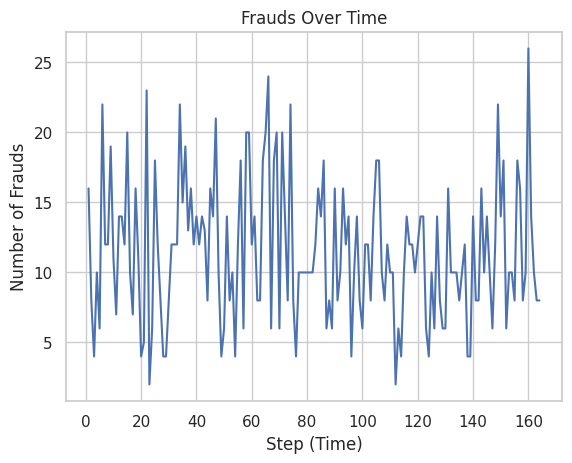

In [ ]:
fraud_per_step=df[df["isFraud"]==1]["step"].value_counts().sort_index()
plt.plot(fraud_per_step.index,fraud_per_step.values,label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [ ]:
df.drop(columns="step",inplace=True)

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [ ]:
top_senders=df["nameOrig"].value_counts().head(10)

In [ ]:
top_senders

,count
nameOrig,
C1999539787,3
C1797117594,2
C1385332440,2
C538429208,2
C28364687,2
C1989615153,2
C2122578711,2
C1547091059,2
C1012825031,2


In [ ]:
top_receivers=df["nameDest"].value_counts().head(10)

In [ ]:
top_receivers

,count
nameDest,
C985934102,100
C1286084959,97
C665576141,94
C248609774,94
C1590550415,91
C2083562754,89
C1360767589,86
C977993101,86
C451111351,85


In [ ]:
fraud_users=df[df["isFraud"]==1]["nameOrig"].value_counts().head(10)

In [ ]:
fraud_users

,count
nameOrig,
C146466047,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C137533655,1
C1118430673,1
C749981943,1
C1334405552,1


In [ ]:
fraud_types=df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [ ]:
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1.0,0.0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1.0,0.0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0.0,0.0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0.0,0.0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0.0,0.0,10835.0,2712905.89


In [ ]:
fraud_types["type"].value_counts()

,count
type,
CASH_OUT,667279
TRANSFER,154020


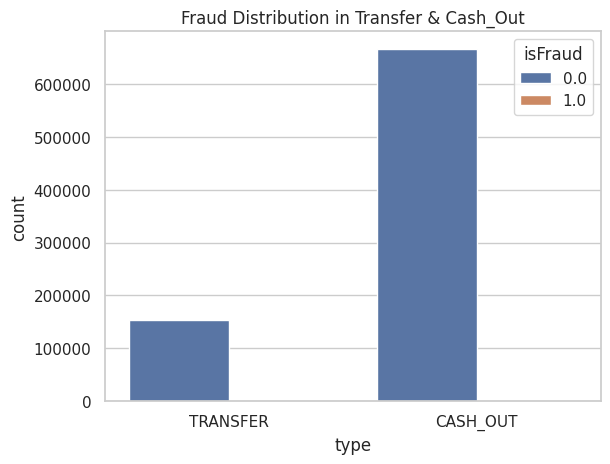

In [ ]:
sns.countplot(data=fraud_types,x="type",hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

In [ ]:
corr=df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [ ]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.001265,-0.004287,0.214469,0.310076,0.132693
oldbalanceOrg,0.001265,1.000000,0.999019,0.092534,0.063108,0.005199
newbalanceOrig,-0.004287,0.999019,1.000000,0.094509,0.062848,-0.008774
oldbalanceDest,0.214469,0.092534,0.094509,1.000000,0.983411,-0.006946
newbalanceDest,0.310076,0.063108,0.062848,0.983411,1.000000,0.000441
isFraud,0.132693,0.005199,-0.008774,-0.006946,0.000441,1.000000


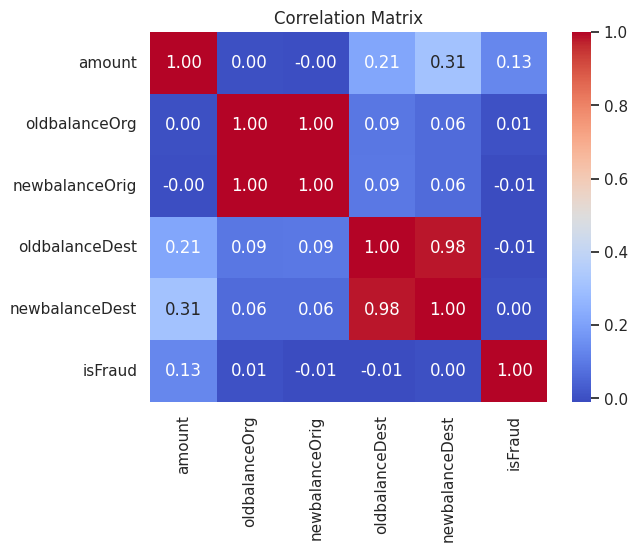

In [ ]:
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
zero_after_transfer=df[
    (df["oldbalanceOrg"]>0)&
    (df["newbalanceOrig"]==0)&
    (df["type"].isin(["TRANSFER","CASH_OUT"]))

]

In [ ]:
len(zero_after_transfer)

349180

In [ ]:
zero_after_transfer

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.00,0.00,1.0,0.0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.00,0.00,1.0,0.0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.00,51513.44,0.0,0.0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.00,0.00,0.0,0.0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.00,2719172.89,0.0,0.0,10835.0,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...
1859318,TRANSFER,258647.52,C1483633662,21331.0,0.0,C893762385,560962.35,819609.87,0.0,0.0,21331.0,258647.52
1859321,CASH_OUT,123560.47,C560493949,57936.0,0.0,C350184293,0.00,123560.47,0.0,0.0,57936.0,123560.47
1859322,CASH_OUT,66463.17,C2009874895,6412.0,0.0,C189941808,313631.96,380095.13,0.0,0.0,6412.0,66463.17
1859324,CASH_OUT,45367.94,C1835752027,12562.0,0.0,C285467043,432259.18,477627.13,0.0,0.0,12562.0,45367.95


In [ ]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,1857446
1.0,1880


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [ ]:
df_model=df.drop(["nameOrig","nameDest","isFlaggedFraud"],axis=1)

In [ ]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0.0


In [ ]:
from numpy._core import numeric
categorical=["type"]
numeric=["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [ ]:
df = df.dropna(subset=["isFraud"])

In [ ]:
y = y.dropna()
X = X.loc[y.index]

In [ ]:
print(y.isnull().sum())

0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="drop"
)

In [ ]:
pipeline=Pipeline([
    ("prep",preprocessor),
    ("clf",LogisticRegression(class_weight="balanced",max_iter=1000))
])

In [ ]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred=(pipeline.predict(X_test))

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    557234
         1.0       0.02      0.98      0.04       564

    accuracy                           0.95    557798
   macro avg       0.51      0.96      0.50    557798
weighted avg       1.00      0.95      0.97    557798



In [ ]:
confusion_matrix(y_test,y_pred)

array([[526907,  30327],
       [    12,    552]])

In [ ]:
pipeline.score(X_test,y_test)*100

94.56093424501343

In [ ]:
import joblib
joblib.dump(pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

In [ ]:
!ls

'AIML Dataset.csv'   fraud_detection_pipeline.pkl   sample_data


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load trained pipeline
model = joblib.load("fraud_detection_pipeline.pkl")

st.title("💳 Fraud Detection Prediction App")

st.markdown("### Enter Transaction Details")
st.divider()

transaction_type = st.selectbox(
    "Transaction Type",
    ["PAYMENT","TRANSFER","CASH_OUT","DEBIT","CASH_IN"]
)

amount = st.number_input("Amount", min_value=0.0)

oldbalanceOrg = st.number_input("Old Balance (Sender)", min_value=0.0)
newbalanceOrig = st.number_input("New Balance (Sender)", min_value=0.0)

oldbalanceDest = st.number_input("Old Balance (Receiver)", min_value=0.0)
newbalanceDest = st.number_input("New Balance (Receiver)", min_value=0.0)

if st.button("Predict Fraud"):

    input_data = pd.DataFrame({
        "type":[transaction_type],
        "amount":[amount],
        "oldbalanceOrg":[oldbalanceOrg],
        "newbalanceOrig":[newbalanceOrig],
        "oldbalanceDest":[oldbalanceDest],
        "newbalanceDest":[newbalanceDest]
    })

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("⚠️ Fraudulent Transaction")
    else:
        st.success("✅ Legitimate Transaction")

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501y


⠙⠹⠸⠼⠴⠦⠧

⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.148.141.24:8501

